# A matplotlib demo

This notebook demonstrates some plotting features of matplotlib.

In [1]:
# import matplotlib, and some packges to make fake data
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats

Create some fake datasets. First, a couple of PDFs...

In [15]:
# normal pdf x and y values for hills
x_pdf = np.linspace(-3,3,100)
normal_pdf = stats.norm.pdf(x_pdf)*12
normal_pdf2 = stats.norm.pdf(x_pdf*1.5)*20

Now, a couple of sine waves...

In [16]:
# x and y values for blue sine waves
x = np.linspace(0,2*np.pi,1000)
y2 =np.sin(x*3)/2 + 3
y3 =np.sin(x*4)/4 + 3

Plot our data using matplotlib, style and annotate the plot with text.

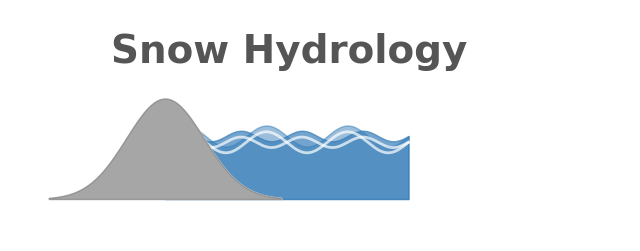

In [17]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(8,3))

# blue sine waves
ax.fill_between(x,y2, np.zeros_like(y2), color='#377EB8', alpha=0.5, zorder=0)
ax.fill_between(x,y3, np.zeros_like(y3), color='#377EB8', alpha=0.7)

# white sine wave lines
ax.plot(x,y2-0.3, c='#fff', lw=2,a zorder=2, alpha=0.7)
ax.plot(x,y3-0.3, c='#fff', lw=2, zorder=2, alpha=0.7)

# green hill pdf
ax.fill_between(x_pdf,normal_pdf, np.zeros_like(normal_pdf), color='grey', alpha=0.7, zorder=2)
ax.fill_between(x_pdf,normal_pdf, np.zeros_like(normal_pdf), color='white', alpha=1, zorder=1)

# # grey hill pdf
# ax.fill_between(x_pdf-2,normal_pdf2, np.zeros_like(normal_pdf), color='grey', alpha=0.7, zorder=2)

# text
ax.text(-1.4,6.5,'Snow Hydrology', size=28, weight='bold', color='#555555', zorder=4)
# ax.text(0.9,5.1,'In Water Sciences', size=17, color='#555555', zorder=4)

# set plot axes limits
ax.set_ylim(-2,9)
ax.set_xlim(-4,12)
# turn off axes lines and labels
ax.axis('off');

# save figure
plt.savefig('logo.svg')

In [20]:
import altair as alt
import pandas as pd

Grab the Ollalie data here:

https://nwcc-apps.sc.egov.usda.gov/awdb/site-plots/POR/WTEQ/WA/Olallie%20Meadows.html?

In [187]:
snotel_df = pd.read_csv("snotel_Olallie_Meadows.csv").set_index('date')

In [188]:
# snotel_df['date_w_random_year'] = 
all_year_columns = ['1983', '1984', '1985', '1986', '1987', '1988', '1989', '1990',
       '1991', '1992', '1993', '1994', '1995', '1996', '1997', '1998', '1999',
       '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008',
       '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017',
       '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025', '2026',]
snotel_df['median'] = snotel_df[all_year_columns].median(axis=1)
snotel_df['min'] = snotel_df[all_year_columns].min(axis=1)
snotel_df['max'] = snotel_df[all_year_columns].max(axis=1)
snotel_df['quantile10'] = snotel_df[all_year_columns].quantile(0.1, axis=1)
snotel_df['quantile30'] = snotel_df[all_year_columns].quantile(0.3, axis=1)
snotel_df['quantile70'] = snotel_df[all_year_columns].quantile(0.7, axis=1)
snotel_df['quantile90'] = snotel_df[all_year_columns].quantile(0.9, axis=1)
snotel_df = snotel_df[['median', 'min', 'max', 'quantile10', 'quantile30', 'quantile70', 'quantile90']]

snotel_df.index = pd.to_datetime('2020-' + snotel_df.index, format='%Y-%m-%d')
snotel_df = snotel_df.rolling(4).median()
snotel_df = snotel_df.reset_index()

In [189]:
snotel_df['day_of_year'] = snotel_df.date.dt.day_of_year
snotel_df['day_of_water_year'] = snotel_df['day_of_year'].apply(
    lambda doy: doy+92 if doy < (365-92) else doy - (365-92)
)

In [190]:
# ALTAIR DEFAULT COLORS
blue = '#1f77b4' 
orange = '#ff7f0e'
green = '#2ca02c'
red = '#d62728'
yellow = '#bcbd22' 
lt_blue = '#17becf'
# '#9467bd' 
# '#8c564b' 
# '#e377c2' 
# '#7f7f7f' 

In [197]:
snotel_df = snotel_df[snotel_df['day_of_water_year'] < 305]
chart_fill_min_to_10 = alt.Chart(snotel_df).mark_line(color=red, opacity=0.1).encode(
    alt.X('day_of_water_year:Q', axis=None),
    alt.Y('min:Q', axis=None), alt.Y2('quantile10:Q')
)
chart_fill_10_to_30 = alt.Chart(snotel_df).mark_line(color=yellow, opacity=0.1).encode(
    alt.X('day_of_water_year:Q', axis=None),
    alt.Y('quantile10:Q', axis=None), alt.Y2('quantile30:Q')
)
chart_fill_30_to_70 = alt.Chart(snotel_df).mark_line(color=green, opacity=0.1).encode(
    alt.X('day_of_water_year:Q', axis=None),
    alt.Y('quantile30:Q', axis=None), alt.Y2('quantile70:Q')
)
chart_fill_70_to_90 = alt.Chart(snotel_df).mark_line(color=lt_blue, opacity=0.15).encode(
    alt.X('day_of_water_year:Q', axis=None),
    alt.Y('quantile70:Q', axis=None), alt.Y2('quantile90:Q')
)
chart_fill_90_to_max = alt.Chart(snotel_df).mark_line(color=blue, opacity=0.1).encode(
    alt.X('day_of_water_year:Q', axis=None),
    alt.Y('quantile90:Q', axis=None), alt.Y2('max:Q')
)
chart_max = alt.Chart(snotel_df).mark_line(color=blue).encode(
    alt.X('day_of_water_year:Q', axis=None),
    alt.Y('max:Q', axis=None)
) 
chart_median = alt.Chart(snotel_df).mark_line(color=green).encode(
    alt.X('day_of_water_year:Q', axis=None),
    alt.Y('median:Q', axis=None)
)
chart_min = alt.Chart(snotel_df).mark_line(color=red).encode(
    alt.X('day_of_water_year:Q', axis=None),
    alt.Y('min:Q', axis=None)
)


combined_chart = chart_max + chart_median + chart_min + fill_min_to_10 + fill_10_to_30 + fill_30_to_70 + fill_70_to_90 + fill_90_to_max
combined_chart.properties(width=600).configure_axis(grid=False, labels=False).configure_view(strokeWidth=0)

# fill_10_to_30
# fill_30_to_70
# fill_70_to_90
# fill_90_to_max

# minimum to 10th percentile , 10th - 30th , 30th - 70th , 70th - 90th , and 90th - maximum.


alt.LayerChart(...)

In [ ]:
snotel_df = snotel_df[snotel_df['day_of_water_year'] < 305]
chart_fill_min_to_10 = alt.Chart(snotel_df).mark_line(color=red, opacity=0.1).encode(
    alt.X('day_of_water_year:Q', axis=None),
    alt.Y('min:Q', axis=None), alt.Y2('quantile10:Q')
)
chart_fill_10_to_30 = alt.Chart(snotel_df).mark_line(color=yellow, opacity=0.1).encode(
    alt.X('day_of_water_year:Q', axis=None),
    alt.Y('quantile10:Q', axis=None), alt.Y2('quantile30:Q')
)
chart_fill_30_to_70 = alt.Chart(snotel_df).mark_line(color=green, opacity=0.1).encode(
    alt.X('day_of_water_year:Q', axis=None),
    alt.Y('quantile30:Q', axis=None), alt.Y2('quantile70:Q')
)
chart_fill_70_to_90 = alt.Chart(snotel_df).mark_line(color=lt_blue, opacity=0.15).encode(
    alt.X('day_of_water_year:Q', axis=None),
    alt.Y('quantile70:Q', axis=None), alt.Y2('quantile90:Q')
)
chart_fill_90_to_max = alt.Chart(snotel_df).mark_line(color=blue, opacity=0.1).encode(
    alt.X('day_of_water_year:Q', axis=None),
    alt.Y('quantile90:Q', axis=None), alt.Y2('max:Q')
)
chart_max = alt.Chart(snotel_df).mark_line(color=blue).encode(
    alt.X('day_of_water_year:Q', axis=None),
    alt.Y('max:Q', axis=None)
) 
chart_median = alt.Chart(snotel_df).mark_line(color=green).encode(
    alt.X('day_of_water_year:Q', axis=None),
    alt.Y('median:Q', axis=None)
)
chart_min = alt.Chart(snotel_df).mark_line(color=red).encode(
    alt.X('day_of_water_year:Q', axis=None),
    alt.Y('min:Q', axis=None)
)


combined_chart = chart_max + chart_median + chart_min + fill_min_to_10 + fill_10_to_30 + fill_30_to_70 + fill_70_to_90 + fill_90_to_max
combined_chart.properties(width=600).configure_axis(grid=False, labels=False).configure_view(strokeWidth=0)

# fill_10_to_30
# fill_30_to_70
# fill_70_to_90
# fill_90_to_max

# minimum to 10th percentile , 10th - 30th , 30th - 70th , 70th - 90th , and 90th - maximum.


alt.LayerChart(...)

In [ ]:
snotel_df = snotel_df[snotel_df['day_of_water_year'] < 305]
chart_fill_min_to_10 = alt.Chart(snotel_df).mark_line(color=red, opacity=0.1).encode(
    alt.X('day_of_water_year:Q', axis=None),
    alt.Y('min:Q', axis=None), alt.Y2('quantile10:Q')
)
chart_fill_10_to_30 = alt.Chart(snotel_df).mark_line(color=yellow, opacity=0.1).encode(
    alt.X('day_of_water_year:Q', axis=None),
    alt.Y('quantile10:Q', axis=None), alt.Y2('quantile30:Q')
)
chart_fill_30_to_70 = alt.Chart(snotel_df).mark_line(color=green, opacity=0.1).encode(
    alt.X('day_of_water_year:Q', axis=None),
    alt.Y('quantile30:Q', axis=None), alt.Y2('quantile70:Q')
)
chart_fill_70_to_90 = alt.Chart(snotel_df).mark_line(color=lt_blue, opacity=0.15).encode(
    alt.X('day_of_water_year:Q', axis=None),
    alt.Y('quantile70:Q', axis=None), alt.Y2('quantile90:Q')
)
chart_fill_90_to_max = alt.Chart(snotel_df).mark_line(color=blue, opacity=0.1).encode(
    alt.X('day_of_water_year:Q', axis=None),
    alt.Y('quantile90:Q', axis=None), alt.Y2('max:Q')
)
chart_max = alt.Chart(snotel_df).mark_line(color=blue).encode(
    alt.X('day_of_water_year:Q', axis=None),
    alt.Y('max:Q', axis=None)
) 
chart_median = alt.Chart(snotel_df).mark_line(color=green).encode(
    alt.X('day_of_water_year:Q', axis=None),
    alt.Y('median:Q', axis=None)
)
chart_min = alt.Chart(snotel_df).mark_line(color=red).encode(
    alt.X('day_of_water_year:Q', axis=None),
    alt.Y('min:Q', axis=None)
)


combined_chart = chart_max + chart_median + chart_min + fill_min_to_10 + fill_10_to_30 + fill_30_to_70 + fill_70_to_90 + fill_90_to_max
combined_chart.properties(width=600).configure_axis(grid=False, labels=False).configure_view(strokeWidth=0)

# fill_10_to_30
# fill_30_to_70
# fill_70_to_90
# fill_90_to_max

# minimum to 10th percentile , 10th - 30th , 30th - 70th , 70th - 90th , and 90th - maximum.


alt.LayerChart(...)